In [1]:
print("Aarya Bhave\nB24CE1110\nTY-2\nDSML Assignment 3")
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Aarya Bhave
B24CE1110
TY-2
DSML Assignment 3


In [2]:
df = pd.read_csv('C:/codes/dsml/accepted_2007_to_2018Q4.csv/accepted_2007_to_2018Q4.csv')
df.head()

C:\Users\Aarya Bhave\AppData\Local\Temp\ipykernel_30776\391799002.py:1: DtypeWarning: Columns (0,19,49,59,118,129,130,131,134,135,136,139,145,146,147) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('C:/codes/dsml/accepted_2007_to_2018Q4.csv/accepted_2007_to_2018Q4.csv')


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
print("Data Information : \n", df.info())
print("Data Shape : ", df.shape)
print("Data Description :", df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Columns: 151 entries, id to settlement_term
dtypes: float64(113), object(38)
memory usage: 2.5+ GB
Data Information : 
 None
Data Shape :  (2260701, 151)
Data Description :        member_id     loan_amnt   funded_amnt  funded_amnt_inv      int_rate  \
count        0.0  2.260668e+06  2.260668e+06     2.260668e+06  2.260668e+06   
mean         NaN  1.504693e+04  1.504166e+04     1.502344e+04  1.309283e+01   
std          NaN  9.190245e+03  9.188413e+03     9.192332e+03  4.832138e+00   
min          NaN  5.000000e+02  5.000000e+02     0.000000e+00  5.310000e+00   
25%          NaN  8.000000e+03  8.000000e+03     8.000000e+03  9.490000e+00   
50%          NaN  1.290000e+04  1.287500e+04     1.280000e+04  1.262000e+01   
75%          NaN  2.000000e+04  2.000000e+04     2.000000e+04  1.599000e+01   
max          NaN  4.000000e+04  4.000000e+04     4.000000e+04  3.099000e+01   

        installment    annual_inc  

In [4]:
print("Null Count : ", df.isnull().sum())

Null Count :  id                             0
member_id                2260701
loan_amnt                     33
funded_amnt                   33
funded_amnt_inv               33
                          ...   
settlement_status        2226455
settlement_date          2226455
settlement_amount        2226455
settlement_percentage    2226455
settlement_term          2226455
Length: 151, dtype: int64


In [5]:
df_clean = df.dropna().copy()

In [6]:
needed_features = [ "loan_amnt",  "grade", "loan_status",  "int_rate",  "installment",  "annual_inc",  "dti", "term",  ] 
df_cleaned=df.copy(needed_features)

In [7]:
df_sub = df[needed_features].copy()

In [9]:
print("Original Data Shape : ", df.shape)
print("Modified Data Shape : ", df_sub.shape)

Original Data Shape :  (2260701, 151)
Modified Data Shape :  (2260701, 8)


In [10]:
print("Null count for modified data : ", df_sub.isnull().sum())

Null count for modified data :  loan_amnt        33
grade            33
loan_status      33
int_rate         33
installment      33
annual_inc       37
dti            1744
term             33
dtype: int64


In [12]:
df_clean = df_sub.dropna().copy()

In [13]:
print("Rechecking Null count for modified data : ", df_clean.isnull().sum())

Rechecking Null count for modified data :  loan_amnt      0
grade          0
loan_status    0
int_rate       0
installment    0
annual_inc     0
dti            0
term           0
dtype: int64


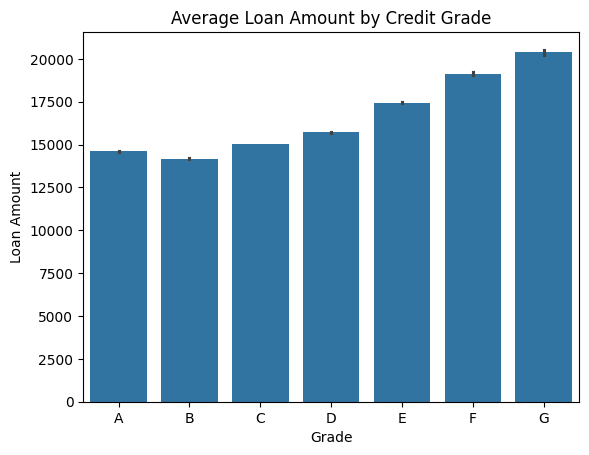

In [15]:
ordered_grades = sorted(df_clean["grade"]) 
sns.barplot(data=df_clean, x="grade",y="loan_amnt",order=ordered_grades) 
plt.title("Average Loan Amount by Credit Grade") 
plt.xlabel("Grade") 
plt.ylabel("Loan Amount") 
plt.show()

In [16]:
df_clean["loan_status"].value_counts()

loan_status
Fully Paid                                             1076448
Current                                                 877018
Charged Off                                             268488
Late (31-120 days)                                       21443
In Grace Period                                           8427
Late (16-30 days)                                         4344
Does not meet the credit policy. Status:Fully Paid        1984
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64

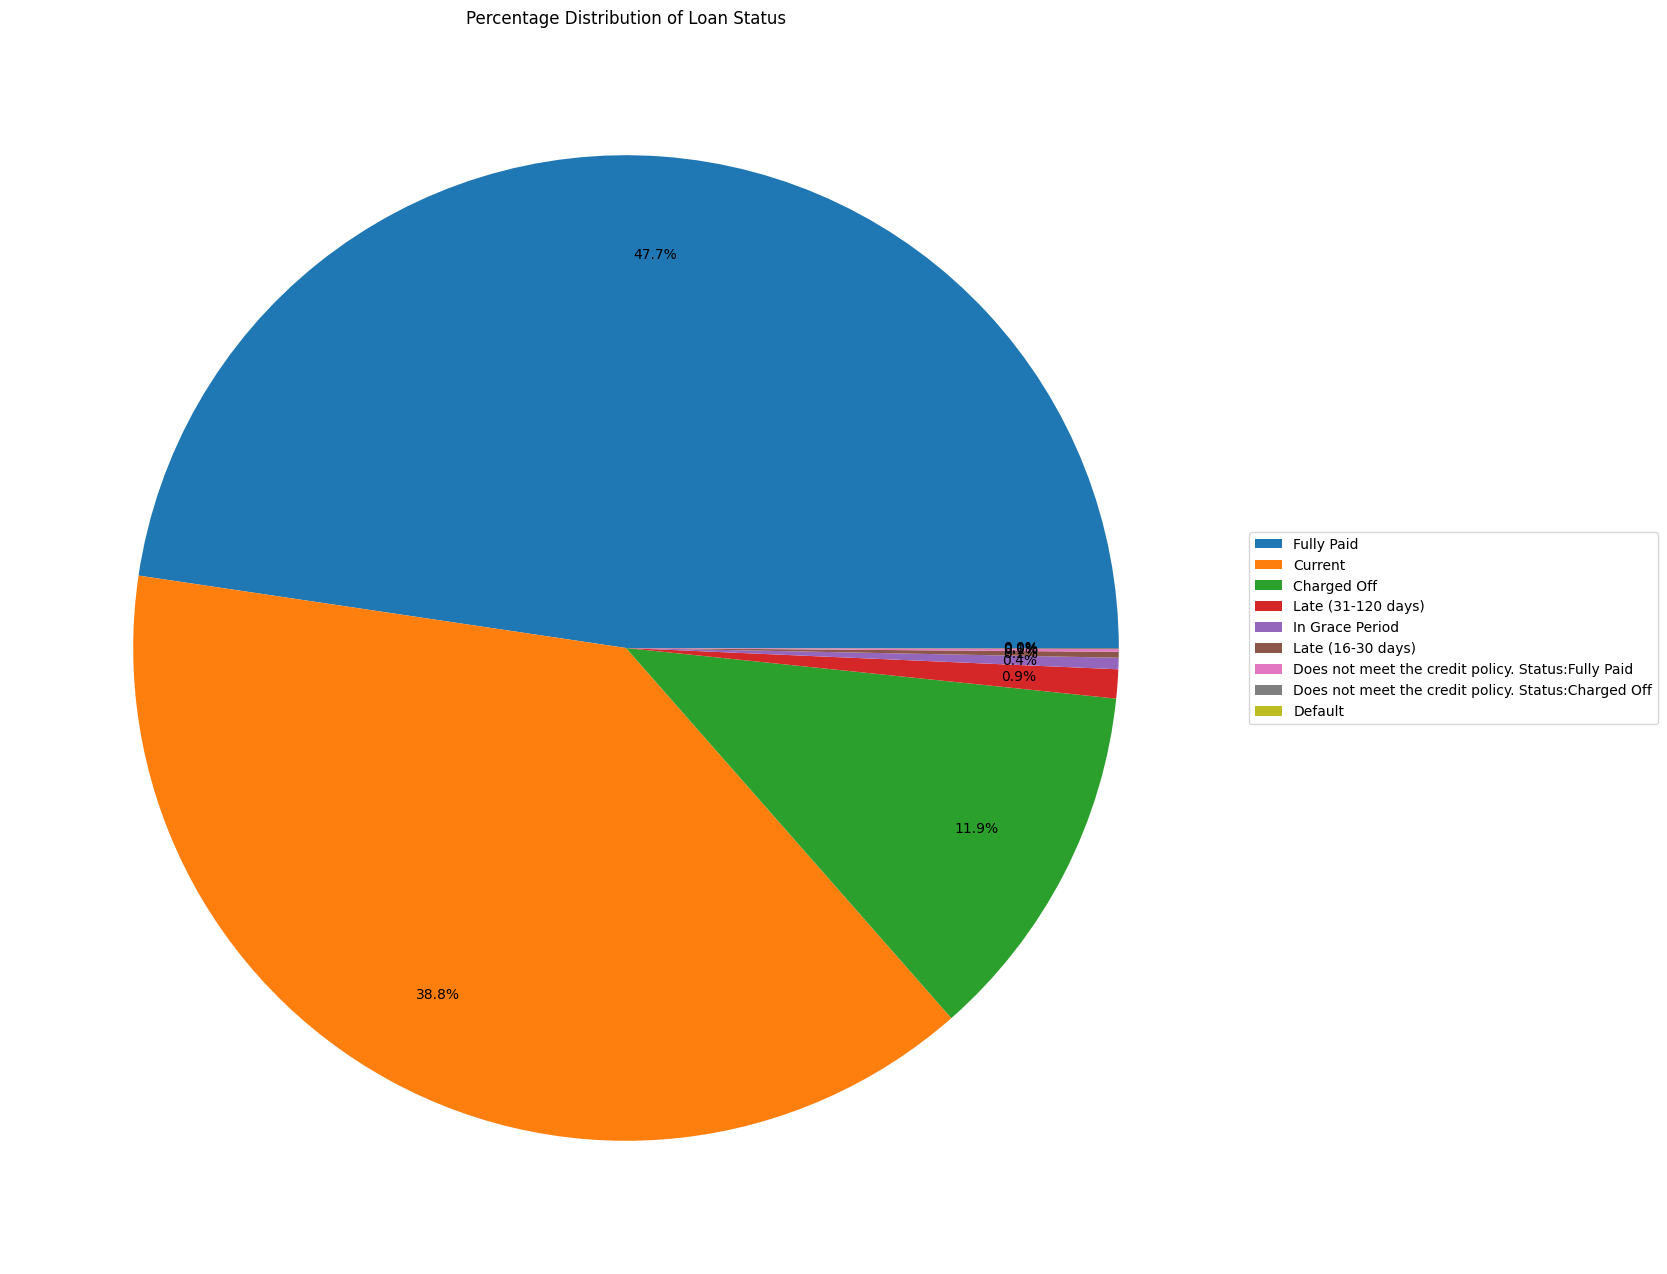

In [17]:
plt.figure(figsize=(16, 16)) 
status = df_clean["loan_status"].value_counts() 
plt.pie(status, labels=None, autopct="%1.1f%%", pctdistance=0.8) 
plt.legend(status.index, bbox_to_anchor=(1, 0.6)) 
plt.title("Percentage Distribution of Loan Status") 
plt.show()

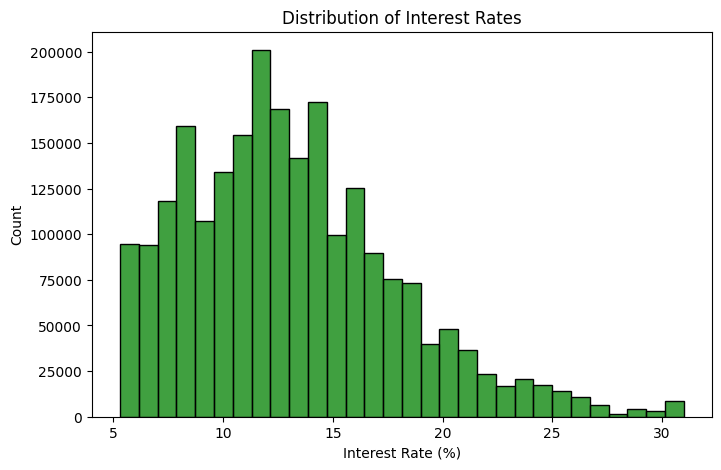

In [18]:
plt.figure(figsize=(8,5)) 
sns.histplot(df_clean["int_rate"],bins=30,color="green")
plt.title("Distribution of Interest Rates") 
plt.xlabel("Interest Rate (%)") 
plt.ylabel("Count") 
plt.show()

In [19]:
df_clean.dtypes

loan_amnt      float64
grade           object
loan_status     object
int_rate       float64
installment    float64
annual_inc     float64
dti            float64
term            object
dtype: object

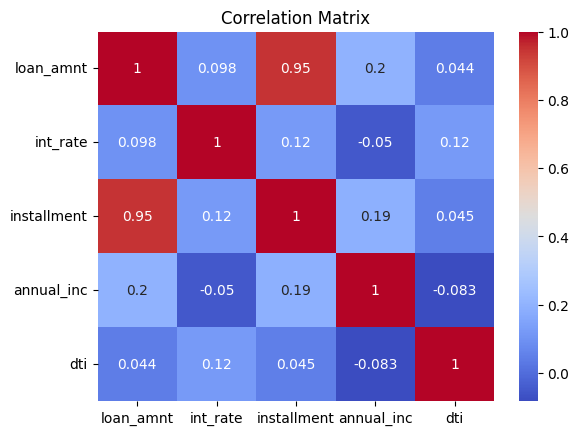

In [21]:
numerical_columns=['loan_amnt','int_rate','installment','annual_inc','dti',] 
sns.heatmap(df_clean[numerical_columns].corr(),annot=True,cmap="coolwarm") 
plt.title("Correlation Matrix") 
plt.show()